In [ ]:
#Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#Load the Handwritten Digit Dataset

#We’ll use load_digits() from scikit-learn — small 8×8 grayscale digit images.
digits = load_digits()

print("Number of images:", len(digits.images))
print("Image shape:", digits.images[0].shape)

Number of images: 1797
Image shape: (8, 8)


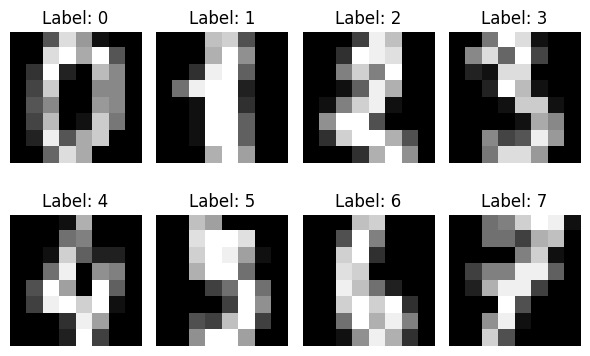

In [ ]:
plt.figure(figsize=(6, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Convert Images to Numbers the Model Can Use
#X = input data = image pixels turned into numbers.
#y = correct answers (0–9).

X = digits.data      # shape: (num_samples, 64)
y = digits.target    # correct digit labels

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1797, 64)
Target vector shape: (1797,)


In [ ]:
#Split into Training & Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1347
Testing samples: 450


In [ ]:
#Choose a Simple Algorithm – k-Nearest Neighbors (k-NN)
#choose k = 5:

knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
#Train the Model
knn.fit(X_train, y_train)
print("Training completed!")

Training completed!


In [ ]:
#Test the Model on New Images
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.33%


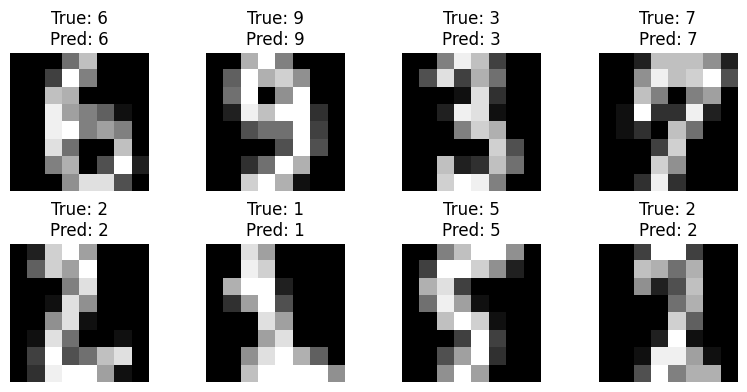

In [ ]:
#Show a Few Predictions Visually

plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        46
           4       0.98      1.00      0.99        55
           5       0.98      0.98      0.98        59
           6       1.00      1.00      1.00        45
           7       1.00      1.00      1.00        41
           8       1.00      1.00      1.00        38
           9       0.98      0.96      0.97        48

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450

Confusion matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  0  0]
 [ 0  0  0  0 55  0  0  0  0  0]
 [ 0  0  0  0  0 58  0  0  0  1]


In [ ]:
#using decision tree
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
#Load MNIST Dataset
#mnist = load_digits()
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target.astype(int)

In [ ]:
#Train–Test Split
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [ ]:
#Train Decision Tree Model
dt = DecisionTreeClassifier(criterion='gini', max_depth=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15)

In [ ]:
#Prediction
y_pred = dt.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8829
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       980
           1       0.95      0.97      0.96      1135
           2       0.86      0.87      0.86      1032
           3       0.85      0.86      0.85      1010
           4       0.88      0.88      0.88       982
           5       0.85      0.84      0.85       892
           6       0.90      0.87      0.89       958
           7       0.92      0.91      0.92      1028
           8       0.84      0.81      0.82       974
           9       0.86      0.87      0.86      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

